In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
print(PROJECT_ROOT)

/Users/florianb/Downloads/ai-customer-insights-engine


In [3]:
import pandas as pd

from src.rag import document_processing

from config import config

In [4]:
import importlib

importlib.reload(config)
importlib.reload(document_processing)

<module 'src.rag.document_processing' from '/Users/florianb/Downloads/ai-customer-insights-engine/src/rag/document_processing.py'>

In [5]:
print(f"REVIEW_MAX_LENGTH = {config.REVIEW_MAX_LENGTH}")
print(f"SEPARATORS = {config.SEPARATORS}")
print(f"CHUNK_SIZE = {config.CHUNK_SIZE}")
print(f"CHUNK_OVERLAP = {config.CHUNK_OVERLAP}")

REVIEW_MAX_LENGTH = 4000
SEPARATORS = ['. ', '! ', '? ', '.', '!', '?', ' ', '']
CHUNK_SIZE = 700
CHUNK_OVERLAP = 100


In [6]:
df_processed = pd.read_parquet(PROJECT_ROOT / "data/processed/processed_reviews_test_notebook.parquet")

In [45]:
df_processed.head()

,publication_date,rating,title,review,experience_date,bank,review_id,year,month,year_month
0,2025-03-07 14:48:17+01:00,5,Banque pas chère,Banque pas chère,2025-03-07,boursobank,0,2025,3,2025-03
1,2025-03-07 14:45:35+01:00,5,Modif plafond retrait,"Gestion aisée de mon compte. Pas de frais, auc...",2025-03-07,boursobank,1,2025,3,2025-03
2,2025-03-07 14:35:24+01:00,5,Facilité,Rajouter un bénéficiaire et tout s'est bien dé...,2025-03-07,boursobank,2,2025,3,2025-03
3,2025-03-07 14:20:03+01:00,4,Trop d'étape de sécurité,J'ai mis 4 étoiles parce que je trouve qu'il a...,2025-03-01,boursobank,3,2025,3,2025-03
4,2025-03-07 13:28:32+01:00,4,Je recommande cette carte pour les…,Je recommande cette carte pour les voyageurs e...,2025-03-06,boursobank,4,2025,3,2025-03


In [8]:
df_processed.info()

<class 'pandas.DataFrame'>
RangeIndex: 48389 entries, 0 to 48388
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype                       
---  ------            --------------  -----                       
 0   publication_date  48389 non-null  datetime64[us, Europe/Paris]
 1   rating            48389 non-null  int64                       
 2   title             48389 non-null  str                         
 3   review            48389 non-null  str                         
 4   experience_date   48389 non-null  datetime64[us]              
 5   bank              48389 non-null  str                         
 6   review_id         48389 non-null  int64                       
 7   year              48389 non-null  int32                       
 8   month             48389 non-null  int32                       
 9   year_month        48389 non-null  str                         
dtypes: datetime64[us, Europe/Paris](1), datetime64[us](1), int32(2), int64(2), str(4)

### Validation de `filter_long_reviews()`

In [28]:
len(df_processed[df_processed["review"].str.len()>4000])

10

In [13]:
filtered_df = document_processing.filter_long_reviews(
    df=df_processed,
    review_max_length=4000,
)

In [29]:
len(filtered_df[filtered_df["review"].str.len()>4000])

0

### Validation de `create_documents()`

In [15]:
filtered_df.head()

,publication_date,rating,title,review,experience_date,bank,review_id,year,month,year_month
0,2025-03-07 14:48:17+01:00,5,Banque pas chère,Banque pas chère,2025-03-07,boursobank,0,2025,3,2025-03
1,2025-03-07 14:45:35+01:00,5,Modif plafond retrait,"Gestion aisée de mon compte. Pas de frais, auc...",2025-03-07,boursobank,1,2025,3,2025-03
2,2025-03-07 14:35:24+01:00,5,Facilité,Rajouter un bénéficiaire et tout s'est bien dé...,2025-03-07,boursobank,2,2025,3,2025-03
3,2025-03-07 14:20:03+01:00,4,Trop d'étape de sécurité,J'ai mis 4 étoiles parce que je trouve qu'il a...,2025-03-01,boursobank,3,2025,3,2025-03
4,2025-03-07 13:28:32+01:00,4,Je recommande cette carte pour les…,Je recommande cette carte pour les voyageurs e...,2025-03-06,boursobank,4,2025,3,2025-03


In [16]:
len(filtered_df)

48379

In [17]:
documents = document_processing.create_documents(
    df=filtered_df,
    dataset_name="processed_reviews_test_notebook",
)

In [18]:
documents[:5]

[Document(metadata={'title': 'Banque pas chère', 'bank': 'boursobank', 'rating': 5, 'publication_date': '2025-03-07T14:48:17+01:00', 'experience_date': '2025-03-07T00:00:00', 'review_id': 0, 'dataset': 'processed_reviews_test_notebook'}, page_content='Banque pas chère'),
 Document(metadata={'title': 'Modif plafond retrait', 'bank': 'boursobank', 'rating': 5, 'publication_date': '2025-03-07T14:45:35+01:00', 'experience_date': '2025-03-07T00:00:00', 'review_id': 1, 'dataset': 'processed_reviews_test_notebook'}, page_content='Gestion aisée de mon compte. Pas de frais, aucun problème.'),
 Document(metadata={'title': 'Facilité', 'bank': 'boursobank', 'rating': 5, 'publication_date': '2025-03-07T14:35:24+01:00', 'experience_date': '2025-03-07T00:00:00', 'review_id': 2, 'dataset': 'processed_reviews_test_notebook'}, page_content="Rajouter un bénéficiaire et tout s'est bien déroulé."),
 Document(metadata={'title': "Trop d'étape de sécurité", 'bank': 'boursobank', 'rating': 4, 'publication_date

In [19]:
len(documents)

48379

### Validation de `chunk_documents()`

In [20]:
chunked_documents = document_processing.chunk_documents(
    documents=documents,
    separators=[". ", "! ", "? ", ".", "!", "?", " ", ""],
    chunk_size=700,
    chunk_overlap=100,
)

In [24]:
len(chunked_documents)

51929

In [93]:
from collections import Counter

# Nombre de chunks par avis
chunks_per_review = Counter(
    chunk.metadata["review_id"] for chunk in chunked_documents
)

# Avis avec au moins 2 chunks
multi_chunk_reviews = {
    review_id for review_id, count in chunks_per_review.items()
    if count >= 2
}

# Chunks issus uniquement de ces avis
chunks_multi = [
    chunk for chunk in chunked_documents
    if chunk.metadata["review_id"] in multi_chunk_reviews
]

# Taille des chunks
chunk_sizes = [len(chunk.page_content) for chunk in chunks_multi]

print(f"Nombre d'avis composés d'au moins 2 chunks : {len(multi_chunk_reviews)} avis")
print(f"Taille moyenne des chunks issus de ces avis : {sum(chunk_sizes)/len(chunk_sizes):.0f} caractères")
print(f"Taille minimale : {min(chunk_sizes)} caractère(s)")
print(f"Taille maximale : {max(chunk_sizes)} caractères")

Nombre d'avis composés d'au moins 2 chunks : 2425 avis
Taille moyenne des chunks issus de ces avis : 483 caractères
Taille minimale : 1 caractère(s)
Taille maximale : 700 caractères


count    5975.00
mean      482.68
std       190.33
min         1.00
25%       337.00
50%       551.00
75%       644.00
max       700.00
dtype: float64


<Axes: >

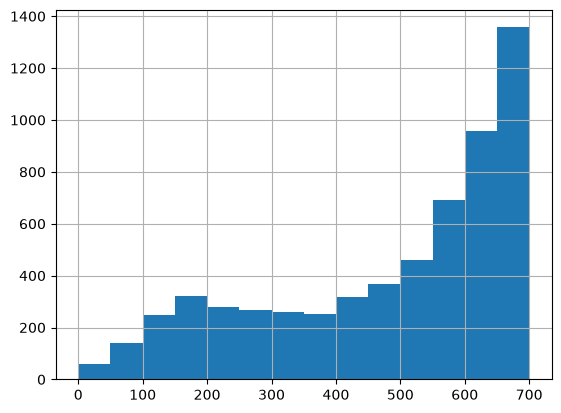

In [104]:
chunk_sizes_series = pd.Series(chunk_sizes)
print(chunk_sizes_series.describe().round(2))
chunk_sizes_series.hist(bins=range(0, 750, 50))

In [105]:
# Chunks de moins de 13 caractères
small_chunks = [
    chunk for chunk in chunked_documents
    if len(chunk.page_content) < 13
]

In [106]:
len(small_chunks)

742

In [109]:
for chunk in small_chunks:
    print(chunk.page_content)

Très simple
Merci merci
Efficacité
Super banque
Très rapide
Excellente
Bonne banque
Super rapide
Rien à dire.
Très rapide
Ras Parfait
Yeeeeeeees
Exceptionnel
Très rapide
Excellente
Banque super
Super bkbjb
Good 👍banque
Très rapide
très facile
Rien à dire.
Très rapide
Super merci
arnaqueurs
Boursobank
Bien j'adore
Bon service
Bon service
Bon courage
Bien níquel
Efficace !!
Très rapide
Excellente
Ultra rapide
Satisfaction
La meilleure
Très rapide
Parfait...
Très fluide
Sécurisation
Rapide merci
Réactivité
Très simple
Bonne appli
Impeccable
Très simple
Efficacité
Très rapide
Très rapide
Honnêtement
La rapidité.
Très facile
Genial cool
Ça a buge...
La rapidité
Impeccable
Aucun souci
Bonne banque
Assez bien.
Réactivité
Super banque
Convivialité
Super facile
Impeccable
Très rapide
Très bien..
Bon service.
Bien facile
Très rapide
BonTout est
Bon service
Exceptionnel
Super rapide
Nickel super
Très positif
Parfait ...
Super rapide
Ok ça marche
Très facile
Parfait!!!
Très facile
Super !!!!!!
Par

### Validation du pipeline `prepare_chunked_documents()` via le notebook

In [110]:
chunked_documents_notebook = document_processing.prepare_chunked_documents(
    input_path=PROJECT_ROOT / "data/processed/processed_reviews_test_notebook.parquet"
)

In [111]:
len(chunked_documents_notebook)

51929

In [112]:
chunked_documents_notebook == chunked_documents

True